In [3]:
import pandas as pd
import numpy as np

files = {
    "Cuttack": r"C:\Users\ASUS\Desktop\IMD\Cuttack_daily_tmax_1995_2024.csv",
    "Kendrapara": r"C:\Users\ASUS\Desktop\IMD\Kendrapara_daily_tmax_1995_2025.csv",
    "Jagatsinghpur": r"C:\Users\ASUS\Desktop\IMD\Jagatsinghpur_daily_tmax_1995_2025.csv"
}

for district, file in files.items():

    df = pd.read_csv(file)

    p90 = np.nanpercentile(df["Tmax"], 90)
    p95 = np.nanpercentile(df["Tmax"], 95)

    print(f"\n{district}")
    print(f"90th percentile = {p90:.2f} °C")
    print(f"95th percentile = {p95:.2f} °C")


Cuttack
90th percentile = 38.24 °C
95th percentile = 39.93 °C

Kendrapara
90th percentile = 37.49 °C
95th percentile = 39.10 °C

Jagatsinghpur
90th percentile = 37.51 °C
95th percentile = 39.07 °C


<Axes: xlabel='Year'>

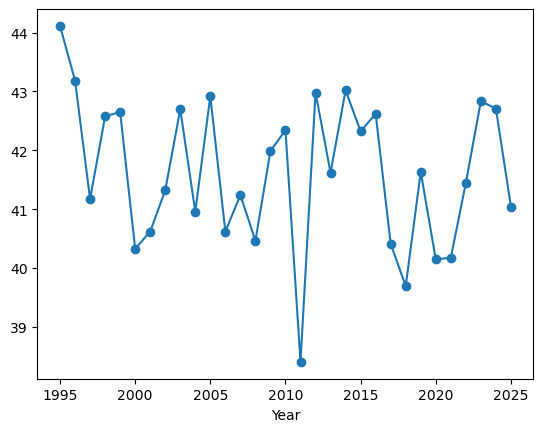

In [4]:
df["Date"] = pd.to_datetime(df["Date"])
df["Year"] = df["Date"].dt.year

annual_max = df.groupby("Year")["Tmax"].max()

annual_max.plot(marker="o")

In [ ]:
Exceeedance days in an year

C:\Users\ASUS\AppData\Local\Temp\ipykernel_2140\1028319856.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x["Tmax"] > threshold).sum())


<Axes: xlabel='Year'>

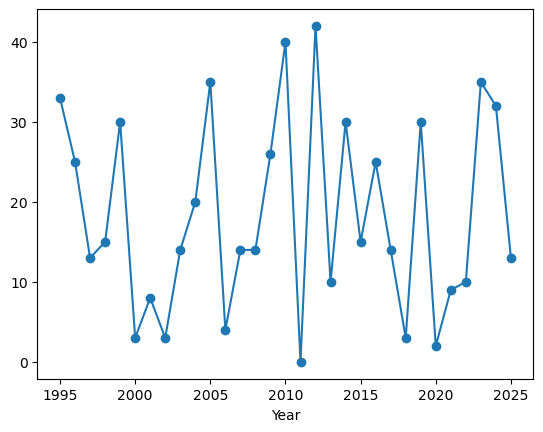

In [8]:

threshold = np.nanpercentile(df["Tmax"],95)

heatwave_days = (
    df.groupby("Year")
      .apply(lambda x: (x["Tmax"] > threshold).sum())
)

heatwave_days.plot(marker="o")

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

cuttack = pd.read_csv(
    r"C:\Users\ASUS\Desktop\IMD\Cuttack_daily_tmax_1995_2024.csv"
)

kendrapara = pd.read_csv(
    r"C:\Users\ASUS\Desktop\IMD\Kendrapara_daily_tmax_1995_2025.csv"
)

jag = pd.read_csv(
    r"C:\Users\ASUS\Desktop\IMD\Jagatsinghpur_daily_tmax_1995_2025.csv"
)

# Make periods consistent
kendrapara = kendrapara[kendrapara["Date"] <= "2024-12-31"]
jag = jag[jag["Date"] <= "2024-12-31"]

for df in [cuttack, kendrapara, jag]:
    df["Date"] = pd.to_datetime(df["Date"])
    df["Year"] = df["Date"].dt.year

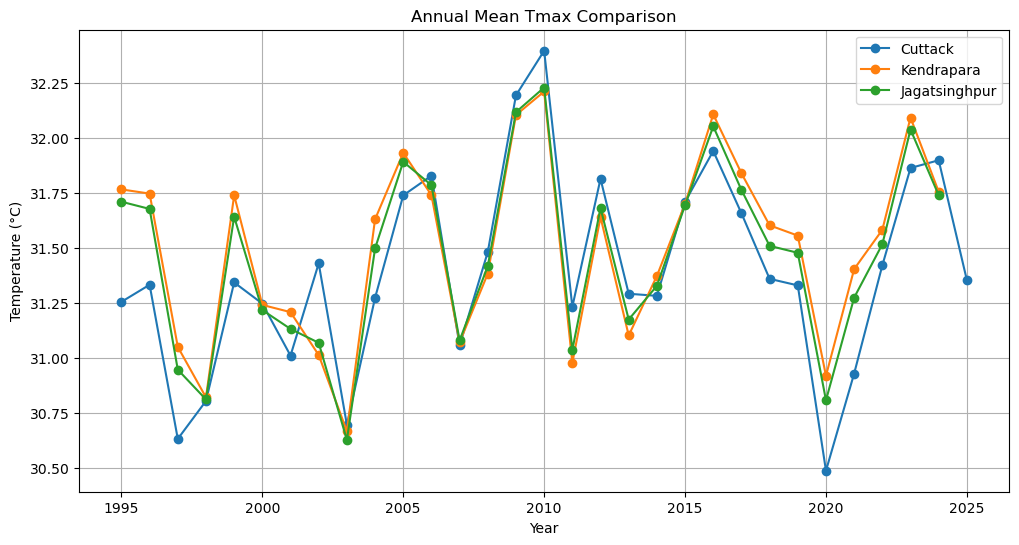

In [12]:
annual_mean_c = cuttack.groupby("Year")["Tmax"].mean()
annual_mean_k = kendrapara.groupby("Year")["Tmax"].mean()
annual_mean_j = jag.groupby("Year")["Tmax"].mean()

plt.figure(figsize=(12,6))

plt.plot(annual_mean_c.index, annual_mean_c.values,
         marker='o', label='Cuttack')

plt.plot(annual_mean_k.index, annual_mean_k.values,
         marker='o', label='Kendrapara')

plt.plot(annual_mean_j.index, annual_mean_j.values,
         marker='o', label='Jagatsinghpur')

plt.title("Annual Mean Tmax Comparison")
plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid(True)

plt.show()

In [21]:
cuttack["District"] = "Cuttack"
kendrapara["District"] = "Kendrapara"
jag["District"] = "Jagatsinghpur"

In [22]:
combined = pd.concat([cuttack, kendrapara, jag])

combined["Date"] = pd.to_datetime(combined["Date"])
combined["Year"] = combined["Date"].dt.year

heatmap_data = (
    combined.groupby(["District", "Year"])["Tmax"]
    .mean()
    .unstack()
)

print(heatmap_data)

Year                1995       1996       1997       1998       1999  \
District                                                               
Cuttack        31.256244  31.333753  30.633580  30.805907  31.344342   
Jagatsinghpur  31.710942  31.678221  30.948161  30.812921  31.642797   
Kendrapara     31.766913  31.747848  31.051727  30.822296  31.740319   

Year                2000       2001       2002       2003       2004  ...  \
District                                                              ...   
Cuttack        31.248193  31.011919  31.430993  30.697651  31.274455  ...   
Jagatsinghpur  31.218941  31.133145  31.070230  30.629029  31.498898  ...   
Kendrapara     31.242215  31.209481  31.014624  30.668772  31.631169  ...   

Year                2016       2017       2018       2019       2020  \
District                                                               
Cuttack        31.941334  31.658688  31.360718  31.330866  30.489156   
Jagatsinghpur  32.053301  31.764673  

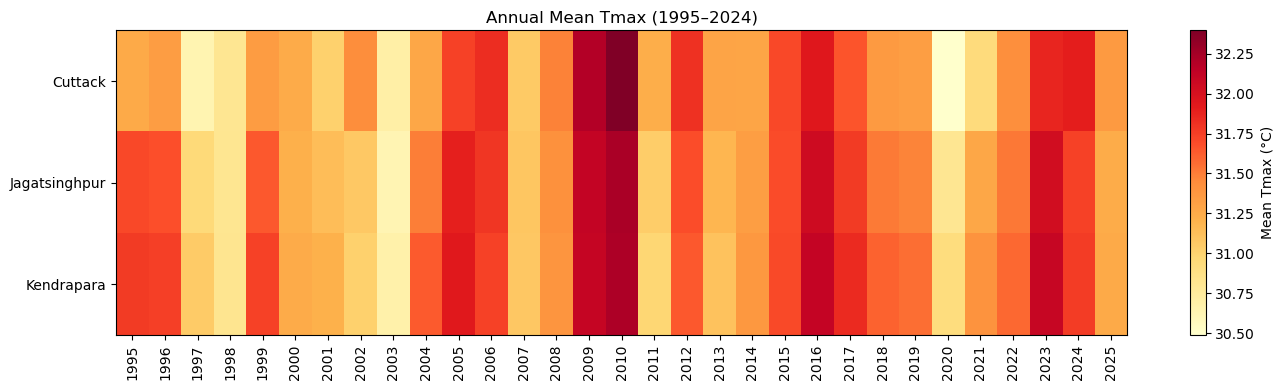

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,4))

im = plt.imshow(
    heatmap_data.values,
    aspect='auto',
    cmap='YlOrRd'
)

plt.colorbar(im, label='Mean Tmax (°C)')

plt.xticks(
    range(len(heatmap_data.columns)),
    heatmap_data.columns,
    rotation=90
)

plt.yticks(
    range(len(heatmap_data.index)),
    heatmap_data.index
)

plt.title("Annual Mean Tmax (1995–2024)")
plt.tight_layout()
plt.show()

In [24]:
import pandas as pd
import numpy as np

cuttack = pd.read_csv("Cuttack_daily_tmax_1995_2024.csv")
kendrapara = pd.read_csv("Kendrapara_daily_tmax_1995_2025.csv")
jag = pd.read_csv("Jagatsinghpur_daily_tmax_1995_2025.csv")

stats = pd.DataFrame({
    "district": ["Cuttack","Kendrapara","Jagatsinghpur"],
    "p95": [
        np.nanpercentile(cuttack["Tmax"],95),
        np.nanpercentile(kendrapara["Tmax"],95),
        np.nanpercentile(jag["Tmax"],95)
    ]
})

print(stats)

        district        p95
0        Cuttack  39.929979
1     Kendrapara  39.097579
2  Jagatsinghpur  39.073986


In [26]:
import os

for root, dirs, files in os.walk(r"C:\Users\ASUS\Desktop\IMD"):
    for file in files:
        if file.endswith(".shp"):
            print(os.path.join(root, file))

C:\Users\ASUS\Desktop\IMD\DISTRICT.shp
C:\Users\ASUS\Desktop\IMD\Odisha.shp


In [33]:
import geopandas as gpd

districts = gpd.read_file(
    r"C:\Users\ASUS\Desktop\IMD\DISTRICT.shp"
)

In [34]:
print(districts["DISTRICT"].unique())

[]


In [36]:
import os

for f in os.listdir(r"C:\Users\ASUS\Desktop\IMD"):
    if "DISTRICT" in f.upper():
        print(f)

DISTRICT.cpg
DISTRICT.dbf
DISTRICT.prj
DISTRICT.qpj
DISTRICT.shp
DISTRICT.shx


In [39]:
odisha = gpd.read_file(r"C:\Users\ASUS\Desktop\IMD\Odisha.shp")

print(odisha.shape)
print(odisha.columns)
odisha.head()

(31, 16)
Index(['ID_0', 'ISO', 'NAME_0', 'ID_1', 'NAME_1', 'ID_2', 'NAME_2', 'ID_3',
       'NAME_3', 'NL_NAME_3', 'VARNAME_3', 'TYPE_3', 'ENGTYPE_3', 'ANU', 'X',
       'geometry'],
      dtype='object')


,ID_0,ISO,NAME_0,ID_1,NAME_1,ID_2,NAME_2,ID_3,NAME_3,NL_NAME_3,VARNAME_3,TYPE_3,ENGTYPE_3,ANU,X,geometry
0,105,IND,India,26,Orissa,375,Bhadrak,1527,Bhadrak,None,None,Taluk,Taluk,None,86.617,"MULTIPOLYGON (((86.94813 20.78457, 86.94814 20..."
1,105,IND,India,26,Orissa,377,Boudh,1531,Bauda,None,None,Taluk,Taluk,None,84.171,"POLYGON ((84.74501 20.60569, 84.75729 20.60296..."
2,105,IND,India,26,Orissa,379,Deogarh,1535,Deogarh,None,None,Taluk,Taluk,None,84.797,"POLYGON ((85.14419 21.58963, 85.15656 21.58408..."
3,105,IND,India,26,Orissa,381,Gajapati,1539,Paralakhemundi,None,None,Taluk,Taluk,None,84.153,"POLYGON ((84.23387 19.56772, 84.2442 19.56407,..."
4,105,IND,India,26,Orissa,383,Jagatsinghpur,1543,Jagatsinghpur,None,None,Taluk,Taluk,None,86.330,"MULTIPOLYGON (((86.38695 19.96278, 86.38695 19..."


In [44]:
districts = odisha.copy()

In [45]:
print(districts["NAME_3"].unique())

['Bhadrak' 'Bauda' 'Deogarh' 'Paralakhemundi' 'Jagatsinghpur' 'Jajapur'
 'Jharsuguda' 'Kendraparha' 'Malakanagiri' 'Nabarangapur' 'Nayagarh'
 'Nuaparha' 'n.a. ( 1507)' 'Puri' 'Sonapur' 'Jaypur' 'Bhawanipatna'
 'Gunupur' 'Bargarh' 'Patnagarh' 'Ghumsur' 'Brahmapur' 'Bhubaneshwar'
 'Athagarh' 'Baripada' 'Baleshwar' 'Anandapur' 'Dhenkanal' 'Anugul'
 'Kuchinda' 'Banei']


In [49]:
import pandas as pd
import numpy as np

stats = pd.DataFrame({
    "NAME_2": [
        "Cuttack",
        "Jagatsinghpur",
        "Kendrapara"
    ],
    "P95": [
        np.nanpercentile(cuttack["Tmax"], 95),
        np.nanpercentile(jag["Tmax"], 95),
        np.nanpercentile(kendrapara["Tmax"], 95)
    ]
})

print(stats)

          NAME_2        P95
0        Cuttack  39.929979
1  Jagatsinghpur  39.073986
2     Kendrapara  39.097579


In [50]:
map_df = districts.merge(
    stats,
    on="NAME_2",
    how="left"
)

print(map_df[["NAME_2", "P95"]].dropna())

           NAME_2        P95
4   Jagatsinghpur  39.073986
7      Kendrapara  39.097579
23        Cuttack  39.929979


(np.float64(81.07802047729491),
 np.float64(87.78764114379912),
 np.float64(17.564561462402285),
 np.float64(22.80163803100586))

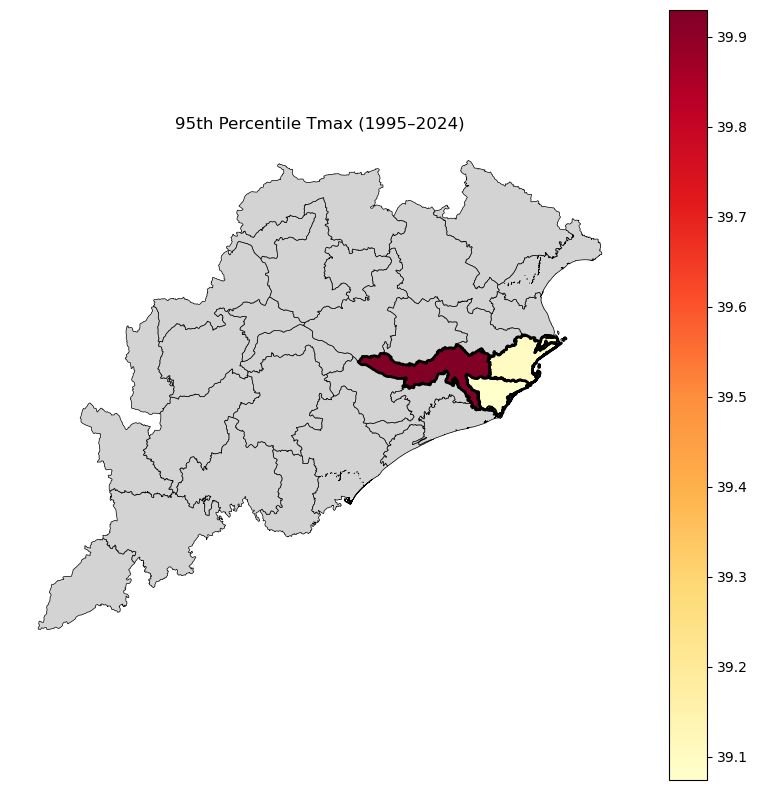

In [51]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10,10))

# All districts in gray
districts.plot(
    ax=ax,
    color="lightgrey",
    edgecolor="black",
    linewidth=0.5
)

# Study districts colored by P95
map_df.dropna(subset=["P95"]).plot(
    column="P95",
    cmap="YlOrRd",
    legend=True,
    edgecolor="black",
    linewidth=2,
    ax=ax
)

plt.title("95th Percentile Tmax (1995–2024)")
plt.axis("off")

<Axes: >

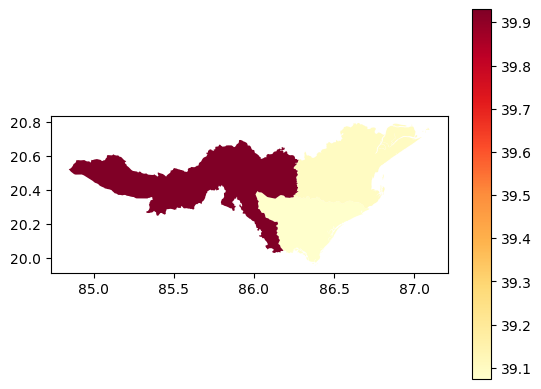

In [57]:
map_df.plot(
    column="P95",
    cmap="YlOrRd",
    legend=True
)

In [58]:
p95_cuttack = np.percentile(cuttack["Tmax"], 95)
p95_kendrapara = np.percentile(kendrapara["Tmax"], 95)
p95_jag = np.percentile(jag["Tmax"], 95)

print(p95_cuttack, p95_kendrapara, p95_jag)

39.92997888422622 39.097579419908776 39.07398623150074


In [59]:
cuttack["Date"] = pd.to_datetime(cuttack["Date"])
cuttack["Year"] = cuttack["Date"].dt.year

heatwave_days = (
    cuttack[cuttack["Tmax"] > p95_cuttack]
    .groupby("Year")
    .size()
)

print(heatwave_days)

Year
1995    30
1996    23
1997    13
1998    19
1999    22
2000     4
2001     7
2002     6
2003    16
2004    17
2005    34
2006     6
2007    13
2008    13
2009    29
2010    46
2011     1
2012    44
2013     9
2014    32
2015    15
2016    24
2017    14
2018     4
2019    30
2020     2
2021     4
2022    13
2023    33
2024    34
2025    10
dtype: int64


In [60]:
def avg_heatwave_days(df):
    
    df = df.copy()
    
    p95 = np.percentile(df["Tmax"], 95)

    df["Date"] = pd.to_datetime(df["Date"])
    df["Year"] = df["Date"].dt.year

    yearly_hw = (
        df[df["Tmax"] > p95]
        .groupby("Year")
        .size()
    )

    return yearly_hw.mean()

avg_hw_cuttack = avg_heatwave_days(cuttack)
avg_hw_kendrapara = avg_heatwave_days(kendrapara)
avg_hw_jag = avg_heatwave_days(jag)

print(avg_hw_cuttack)
print(avg_hw_kendrapara)
print(avg_hw_jag)

18.29032258064516
18.9
18.9


In [61]:
stats = pd.DataFrame({
    "NAME_2": [
        "Cuttack",
        "Kendrapara",
        "Jagatsinghpur"
    ],
    "HeatwaveDays": [
        avg_hw_cuttack,
        avg_hw_kendrapara,
        avg_hw_jag
    ]
})

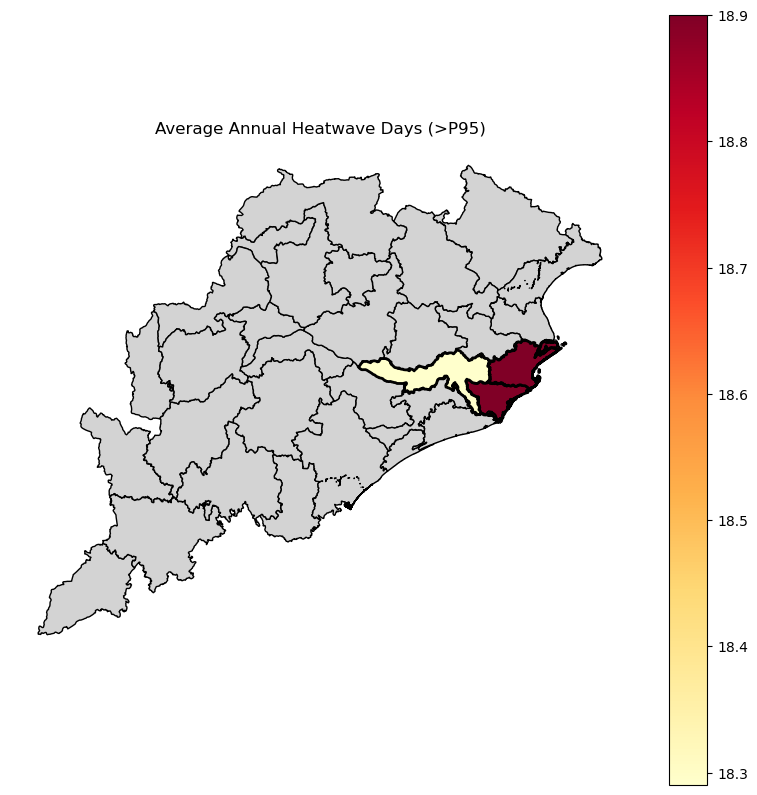

In [62]:
map_df = districts.merge(
    stats,
    on="NAME_2",
    how="left"
)

fig, ax = plt.subplots(figsize=(10,10))

districts.plot(
    ax=ax,
    color="lightgrey",
    edgecolor="black"
)

map_df.dropna(subset=["HeatwaveDays"]).plot(
    column="HeatwaveDays",
    cmap="YlOrRd",
    legend=True,
    edgecolor="black",
    linewidth=2,
    ax=ax
)

plt.title("Average Annual Heatwave Days (>P95)")
plt.axis("off")
plt.show()